<a href="https://www.kaggle.com/code/ahmedfakhar123/ml-25-feature-selection-splitting?scriptVersionId=341430251" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

---
# 🤖 ML 25 — Feature Selection & Splitting

### **Select the most useful features and split data correctly for machine learning**

---

# 📌 Introduction

Feature selection is the process of selecting the most relevant features for a machine learning model while removing unnecessary or redundant variables.

In this notebook, we will use the **House Prices — Advanced Property Features** dataset to learn how to:

- Split data into training and testing sets
- Separate features from the target variable
- Remove irrelevant features
- Analyze feature correlation
- Select important numerical features
- Use statistical feature selection with `SelectKBest`
- Understand why feature selection should be performed without data leakage

---
# 📚 What is Feature Selection?

Feature selection means choosing the most useful input variables from a dataset.

For example, our dataset contains features such as:

- `OverallQual`
- `GrLivArea`
- `GarageArea`
- `YearBuilt`
- `LotArea`
- `PoolArea`

Not every feature contributes equally to predicting `SalePrice`.

### Why Feature Selection?

Feature selection can help:

- 🎯 Reduce unnecessary features
- 📉 Reduce model complexity
- ⚡ Improve training speed
- 🧠 Make models easier to interpret
- 🛡️ Reduce the risk of overfitting

---
# 📦 Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

---
# 📂 Load Dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/ahmedfakhar123/house-prices-advanced-property-features/train.csv")
df

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [3]:
df.shape

(1460, 81)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

The dataset contains a mixture of numerical and categorical variables describing residential properties.

Our target variable is:

`SalePrice`

which represents the final sale price of each property.

---
# 🎯 Separate Features and Target

In [5]:
X = df.drop(columns="SalePrice")
y = df["SalePrice"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (1460, 80)
Target: (1460,)


---
# ✂️ Train-Test Split

Before performing feature selection, we should divide the dataset into training and testing sets.

The training set is used to:

- Learn patterns
- Train the model
- Select features

The test set is kept separate and is used only for final evaluation.

This prevents **data leakage**.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1168, 80)
Testing data: (292, 80)


---
# 🧹 Select Numerical Features

The dataset contains categorical columns such as `Neighborhood`, `HouseStyle`, and `GarageType`.

For our first feature-selection experiment, we'll work with numerical features

In [7]:
X_train_num = X_train.select_dtypes(include=np.number)
X_test_num = X_test.select_dtypes(include=np.number)

print("Numerical features:", X_train_num.shape[1])

Numerical features: 37


---
# 🧹 Handle Missing Values

Some numerical features contain missing values.

In [8]:
X_train_num = X_train_num.fillna(X_train_num.median())
X_test_num = X_test_num.fillna(X_train_num.median())

---
# 📊 Step 1: Correlation-Based Feature Selection

## 📊 Correlation with `SalePrice`

Correlation measures the relationship between numerical features and the target.

For this regression problem, we can inspect the Pearson correlation between each numerical feature and `SalePrice`.

A higher absolute correlation indicates a stronger linear relationship.

In [9]:
correlation = X_train_num.corrwith(y_train).abs().sort_values(ascending=False)

correlation.head(15)

OverallQual     0.785555
GrLivArea       0.695652
GarageCars      0.640991
GarageArea      0.624139
TotalBsmtSF     0.597766
1stFlrSF        0.587883
FullBath        0.552546
TotRmsAbvGrd    0.520388
YearBuilt       0.516501
YearRemodAdd    0.508593
GarageYrBlt     0.459810
MasVnrArea      0.457608
Fireplaces      0.457549
BsmtFinSF1      0.359460
WoodDeckSF      0.329843
dtype: float64

## 🔥 Visualize Top Correlations

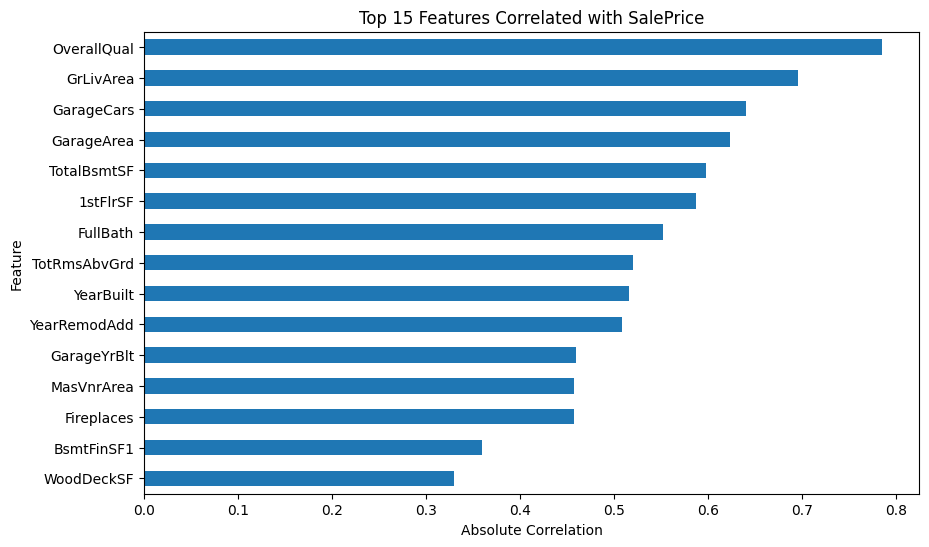

In [10]:
plt.figure(figsize=(10, 6))

correlation.head(15).sort_values().plot(kind="barh")

plt.title("Top 15 Features Correlated with SalePrice")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.show()

## 🎯 Select Top Features

In [11]:
top_features = correlation.head(10).index

top_features

Index(['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF',
       '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd'],
      dtype='object')

In [12]:
X_train_selected = X_train_num[top_features]
X_test_selected = X_test_num[top_features]

print("Selected features:")
print(list(top_features))

Selected features:
['OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea', 'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt', 'YearRemodAdd']


---
# 🧪 Step 2: Feature Selection with SelectKBest

## 🧪 SelectKBest

`SelectKBest` selects the **K best features** according to a statistical scoring function.

For regression problems, `f_regression` can be used to calculate an F-statistic and corresponding score for each feature.

Here, we'll select the top 10 features.

In [13]:
selector = SelectKBest(
    score_func=f_regression,
    k=10
)

X_train_kbest = selector.fit_transform(
    X_train_num,
    y_train
)

X_test_kbest = selector.transform(
    X_test_num
)

## 📋 Get Selected Feature Names

In [14]:
selected_features = X_train_num.columns[
    selector.get_support()
]

selected_features

Index(['OverallQual', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF',
       'GrLivArea', 'FullBath', 'TotRmsAbvGrd', 'GarageCars', 'GarageArea'],
      dtype='object')

In [15]:
feature_scores = pd.DataFrame({
    "Feature": X_train_num.columns,
    "Score": selector.scores_
})

feature_scores = feature_scores.sort_values(
    by="Score",
    ascending=False
)

feature_scores.head(10)

,Feature,Score
4,OverallQual,1879.151818
16,GrLivArea,1093.390361
26,GarageCars,813.186816
27,GarageArea,744.064301
12,TotalBsmtSF,648.289096
13,1stFlrSF,615.803607
19,FullBath,512.439469
23,TotRmsAbvGrd,433.021675
6,YearBuilt,424.230726
7,YearRemodAdd,406.841796


## 📈 Visualize SelectKBest Scores

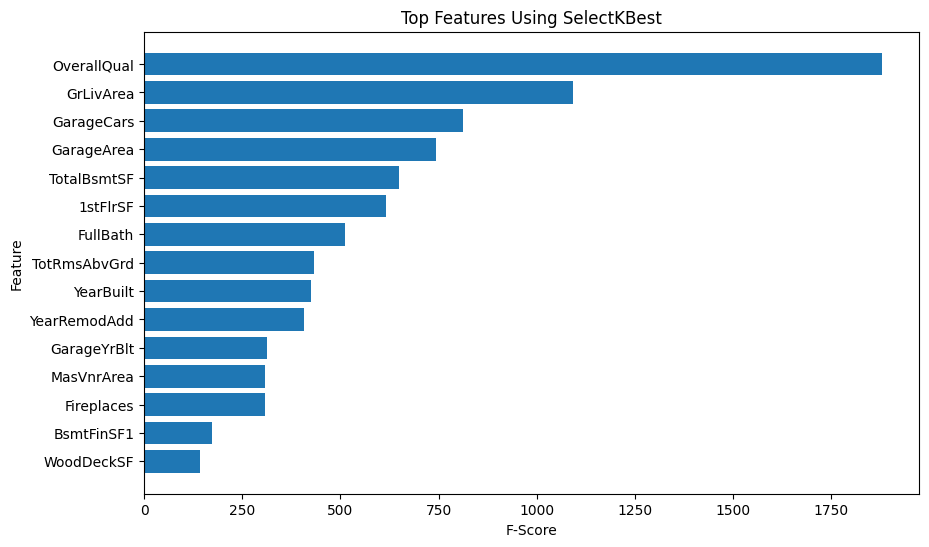

In [16]:
plt.figure(figsize=(10, 6))

top_scores = feature_scores.head(15).sort_values("Score")

plt.barh(
    top_scores["Feature"],
    top_scores["Score"]
)

plt.title("Top Features Using SelectKBest")
plt.xlabel("F-Score")
plt.ylabel("Feature")

plt.show()

---
# 🤖 Training a Model

Now we'll train a `RandomForestRegressor` using only the features selected by `SelectKBest`.

This allows us to compare a model using selected features with the available numerical features.

In [17]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_kbest, y_train)

y_pred = model.predict(X_test_kbest)

---
# 📊 Evaluating the Model

In [18]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R² Score:", r2)

RMSE: 29362.523197914874
R² Score: 0.8875982917466738


---
# 🌳 Feature Importance

Another useful way to understand feature relevance is through model-based feature importance.

In [19]:
importance = pd.DataFrame({
    "Feature": selected_features,
    "Importance": model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,OverallQual,0.571185
5,GrLivArea,0.166974
3,TotalBsmtSF,0.066722
4,1stFlrSF,0.049536
9,GarageArea,0.036498
1,YearBuilt,0.034737
2,YearRemodAdd,0.029400
8,GarageCars,0.018380
7,TotRmsAbvGrd,0.015565
6,FullBath,0.011004


<Figure size 1000x600 with 0 Axes>

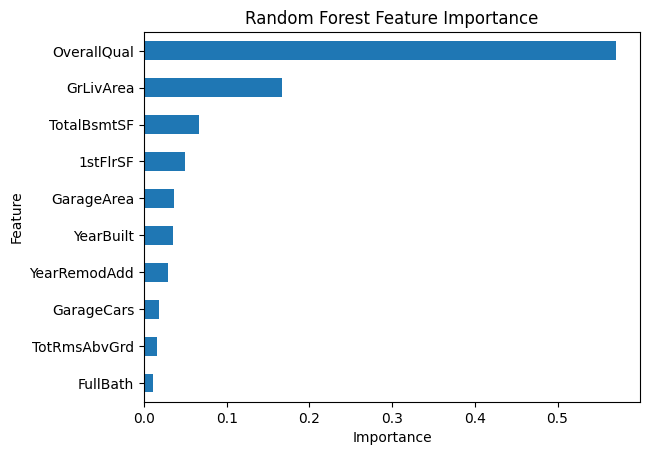

In [20]:
plt.figure(figsize=(10, 6))

importance.sort_values("Importance").plot(
    x="Feature",
    y="Importance",
    kind="barh",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

---
# 🔄 Comparing Feature Selection Methods

We used two different approaches:

## 1. Correlation
Looks for features that have a strong linear relationship with the target.

## 2. SelectKBest
Uses a statistical test to rank features according to their relationship with the target.

## 3. Model-Based Importance
Uses a machine learning model to estimate how useful each feature is for prediction.

Different methods can select different features because they measure feature importance in different ways.

---
# 🏁 Conclusion

In this notebook, we explored **Feature Selection & Splitting** using the House Prices dataset.

We learned how to:

- Split data into training and testing sets
- Separate features from the target
- Remove irrelevant variables
- Analyze feature-target correlations
- Select important features using `SelectKBest`
- Evaluate a model using selected features
- Understand model-based feature importance
- Avoid data leakage during feature selection

Feature selection is an important part of the machine learning pipeline because **more features do not always mean a better model**. Selecting useful features can make models simpler, faster, and easier to interpret.

---